In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_samples = 200

data = pd.DataFrame({
    "Revenue_Millions": np.random.randint(10, 1000, n_samples),
    "Employees": np.random.randint(50, 10000, n_samples),
    "Market_Growth_%": np.random.uniform(-5, 20, n_samples),
    "R&D_Spend_%": np.random.uniform(0, 25, n_samples),
    "Automation_Level": np.random.randint(1, 10, n_samples),
    "Global_Presence": np.random.randint(0, 2, n_samples),
    "Industry_Type": np.random.choice(["Tech", "Manufacturing", "Healthcare", "Finance"], n_samples)
})

data.to_csv("industries.csv", index=False)
data.head()

,Revenue_Millions,Employees,Market_Growth_%,R&D_Spend_%,Automation_Level,Global_Presence,Industry_Type
0,112,1807,1.354091,17.025986,9,0,Tech
1,445,7624,2.382265,5.937662,1,0,Healthcare
2,870,6424,3.063769,10.005572,5,1,Tech
3,280,6942,16.216745,11.942872,6,0,Manufacturing
4,116,1728,-1.584467,2.072283,5,0,Manufacturing


In [2]:
import pandas as pd

df = pd.read_csv("industries.csv")

# Features and target
X = df.drop("Industry_Type", axis=1)
y = df["Industry_Type"]

# Encode categorical target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.15

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.31      0.33      0.32        12
           2       0.08      0.12      0.10         8
           3       0.08      0.10      0.09        10

    accuracy                           0.15        40
   macro avg       0.12      0.14      0.13        40
weighted avg       0.13      0.15      0.14        40



In [5]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42
)

et_model.fit(X_train, y_train)

et_preds = et_model.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, et_preds))
print("\nClassification Report:\n", classification_report(y_test, et_preds))

Extra Trees Accuracy: 0.175

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.21      0.25      0.23        12
           2       0.18      0.25      0.21         8
           3       0.15      0.20      0.17        10

    accuracy                           0.17        40
   macro avg       0.14      0.17      0.15        40
weighted avg       0.14      0.17      0.15        40



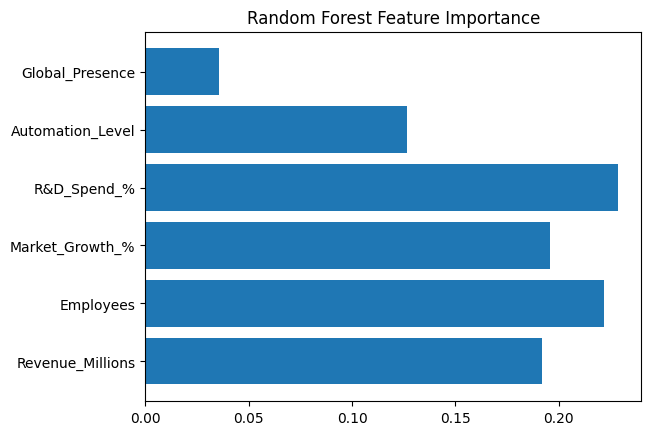

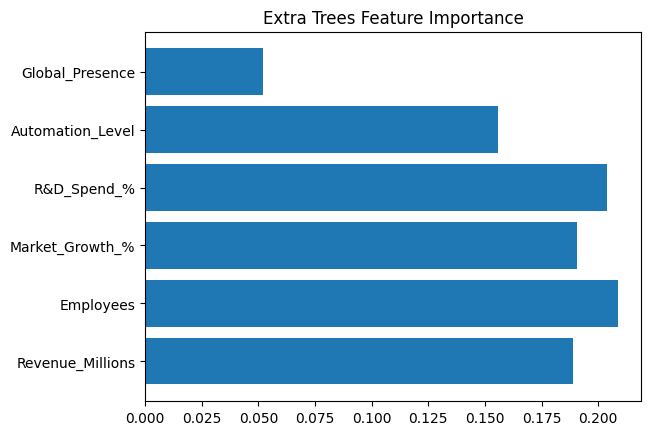

In [6]:
import matplotlib.pyplot as plt

features = X.columns

rf_importance = rf_model.feature_importances_
et_importance = et_model.feature_importances_

plt.figure()
plt.barh(features, rf_importance)
plt.title("Random Forest Feature Importance")
plt.show()

plt.figure()
plt.barh(features, et_importance)
plt.title("Extra Trees Feature Importance")
plt.show()